In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from google.colab import drive
import os

target_dir = '/content/drive/MyDrive/Colab Notebooks'

if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')

if os.getcwd() != target_dir:
    os.chdir(target_dir)

print(f"[/content/drive/MyDrive] mounted  : {os.path.isdir('/content/drive/MyDrive')} \n os.chdir : {os.getcwd()}")

from harmonicSearch import *

tf.random.set_seed(777) # 하이퍼파라미터 튜닝을 위해 실행시 마다 변수가 같은 초기값 가지게 하기

[/content/drive/MyDrive] mounted  : True 
 os.chdir : /content/drive/MyDrive/Colab Notebooks


In [2]:

model_ripple = tf.keras.models.Sequential([
    layers.Input(shape=(4,)),

    layers.Dense(30), # wx+b
    layers.BatchNormalization(), # 정규화
    layers.LeakyReLU(alpha=0.01), # Relu, tanh

    layers.Dense(10),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.01),

    layers.Dense(2),  #  Iripple, Vripple,
])

model_leakage_current = tf.keras.models.Sequential([
    layers.Input(shape=(4,)),

    layers.Dense(30), # wx+b
    layers.BatchNormalization(), # 정규화
    layers.LeakyReLU(alpha=0.01),

    layers.Dense(10),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.01),

    layers.Dense(1),  #  Iripple, Vripple,
])

model_ripple.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse', # Mean Squared Error
    metrics=['mae'] # Mean Absolute Error, metrics : 학습지표 = 학습에 영향은 안미침
)


model_leakage_current.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse', # Mean Squared Error
    metrics=['mae'] # Mean Absolute Error, metrics : 학습지표 = 학습에 영향은 안미침
)

# model_ripple.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [3]:

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/L2_sin.csv", encoding = "UTF-8")


In [4]:
df_ccm = df[
    df[["Conduction_Mode_L1", "Conduction_Mode_L2"]]
    .eq("CCM")
    .all(axis=1)
]
print(f"행 개수 :  {len(df_ccm)}")

X = df_ccm[['L1', 'L2', 'C1', 'F']].values
y_ripple  = df_ccm[['i_L1_ripple_rate', 'v_ripple_rate']].values
y_leakage = df_ccm[['leakage_avg']].values

print("X sample:")
print(X[:5])

print("\ny sample:")
print(y_ripple[:5])

# 70% train, 30% temp
X_train, X_temp, y_ripple_train, y_ripple_temp, y_leakage_train, y_leakage_temp= train_test_split(
    X, y_ripple, y_leakage,
    test_size=0.30,
    random_state=42
)

# 15% val, 15% test
X_val, X_test, y_ripple_val, y_ripple_test, y_leakage_val, y_leakage_test= train_test_split(
    X_temp, y_ripple_temp, y_leakage_temp,
    test_size=0.50,
    random_state=42
)

print(f'len(X_train) : {len(X_train)}')
print(f'len(X_test) : {len(X_test)}')
print(f'len(X_val) : {len(X_val)}')


행 개수 :  8247
X sample:
[[1.0e-04 6.0e-05 1.0e-05 8.0e+04]
 [1.0e-04 1.1e-04 1.0e-05 8.0e+04]
 [1.0e-04 1.6e-04 1.0e-05 8.0e+04]
 [1.0e-04 2.1e-04 1.0e-05 8.0e+04]
 [1.0e-04 2.6e-04 1.0e-05 8.0e+04]]

y sample:
[[2.12995922 0.37420643]
 [2.1521589  0.37445388]
 [2.18050825 0.3746765 ]
 [2.19213199 0.37554121]
 [2.2041087  0.3759712 ]]
len(X_train) : 5772
len(X_test) : 1238
len(X_val) : 1237


## Scaler

In [5]:
# HS용
y_ripple_mmscaler  = MinMaxScaler()
y_leakage_mmscaler = MinMaxScaler()

y_ripple_mmscaler.fit_transform(y_ripple)
y_leakage_mmscaler.fit_transform(y_leakage)

x_scaler = MinMaxScaler()
y_ripple_scaler  = StandardScaler()
y_leakage_scaler = StandardScaler()

# 학습용
X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

y_ripple_train = y_ripple_scaler.fit_transform(y_ripple_train)
y_ripple_val   = y_ripple_scaler.transform(y_ripple_val)
y_ripple_test  = y_ripple_scaler.transform(y_ripple_test)

y_leakage_train = y_leakage_scaler.fit_transform(y_leakage_train)
y_leakage_val   = y_leakage_scaler.transform(y_leakage_val)
y_leakage_test  = y_leakage_scaler.transform(y_leakage_test)




In [6]:
history_ripple = model_ripple.fit(
    X_train, y_ripple_train,
    validation_data=(X_val, y_ripple_val),
    epochs=100, # 반복 횟수
    batch_size=100, # 한 train에 넣는 input set 개수. -> (train data set 개수 / batch size) = 한 epoch 에 반복하는 수.
    verbose=0
)

In [7]:
history_leakage = model_leakage_current.fit(
    X_train, y_leakage_train,
    validation_data=(X_val, y_leakage_val),
    epochs=100,
    batch_size=100,
    verbose=0
)

In [8]:
test_loss, test_mae = model_ripple.evaluate(X_test, y_ripple_test) # Test set 확인
print("Test MAE:", test_mae)
test_loss, test_mae = model_leakage_current.evaluate(X_test, y_leakage_test) # Test set 확인
print("Test MAE:", test_mae)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0099 - mae: 0.0666
Test MAE: 0.06660720705986023
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0126 - mae: 0.0843
Test MAE: 0.08426543325185776


# hs

In [9]:
from harmonicSearch import *

In [10]:
hs_result = harmony_search(model_ripple = model_ripple,
                           model_leakage_current = model_leakage_current,
                           x_scaler = x_scaler,
                           y_ripple_scaler = y_ripple_scaler,
                           y_leakage_scaler = y_leakage_scaler,
                           y_ripple_mmscaler = y_ripple_mmscaler,
                           y_leakage_mmscaler = y_leakage_mmscaler,
                           max_iters = 1000,
                           hmcr = 0.7,
                           )

Initialize HM ...
[1 / 1000] best_f = 1.009, best_m={'lripple': np.float32(1.5368953), 'vripple': np.float32(0.29241416), 'leakage': np.float32(-1.7180237e-07)}
[2 / 1000] best_f = 1.009, best_m={'lripple': np.float32(1.5368953), 'vripple': np.float32(0.29241416), 'leakage': np.float32(-1.7180237e-07)}
[3 / 1000] best_f = 1.009, best_m={'lripple': np.float32(1.5368953), 'vripple': np.float32(0.29241416), 'leakage': np.float32(-1.7180237e-07)}
[4 / 1000] best_f = 1.009, best_m={'lripple': np.float32(1.5368953), 'vripple': np.float32(0.29241416), 'leakage': np.float32(-1.7180237e-07)}
[5 / 1000] best_f = 1.009, best_m={'lripple': np.float32(1.5368953), 'vripple': np.float32(0.29241416), 'leakage': np.float32(-1.7180237e-07)}
[6 / 1000] best_f = 1.009, best_m={'lripple': np.float32(1.5368953), 'vripple': np.float32(0.29241416), 'leakage': np.float32(-1.7180237e-07)}
[7 / 1000] best_f = 1.009, best_m={'lripple': np.float32(1.5368953), 'vripple': np.float32(0.29241416), 'leakage': np.float3

In [11]:
# sample = np.array([[0.000774555259538101, 0.000392384937550832, 83286.43757508445]]) # 0.147588455	6.89E-05	CCM
# sample_scaled = x_scaler.transform(sample) #스케일링
# sample_pred_scaled = model_leakage_current.predict(sample_scaled)
# sample_pred = y_leakage_scaler.inverse_transform(sample_pred_scaled) # 역스케일링

# print(sample_pred)


# sample = np.array([[0.00099187982178617, 0.00043642916949729365, 86873.74846328597]]) # 0.147588455	6.89E-05	CCM
# sample_scaled = x_scaler.transform(sample) #스케일링
# sample_pred_scaled = model_leakage_current.predict(sample_scaled)
# sample_pred = y_leakage_scaler.inverse_transform(sample_pred_scaled) # 역스케일링

# print(sample_pred)

#Ga

In [12]:
import numpy as np

def fitness_func(ga_instance, solution, solution_idx):

    x_dict = {
        "L1": solution[0],
        "L2": solution[1],
        "C": solution[2],
        "fsw": solution[3],
    }

    # 🔹 모델 예측
    metrics = evaluate_lt(model_ripple,
                          model_leakage_current,
                          x_scaler,
                          y_ripple_scaler,
                          y_leakage_scaler,
                          x_dict)

    lr = metrics["lripple"]
    vr = metrics["vripple"]
    leakage_c = metrics["leakage"]

    penalty_term = (
        1e7 * (min(0, lr)**2) +
        1e7 * (min(0, vr)**2) +
        1e7 * (min(0, leakage_c)**2)
    )

    lr = max(0.0, lr)
    vr = max(0.0, vr)
    leakage_c = max(0.0, leakage_c)

    ripple = np.array([[lr, vr]])
    ripple_norm = y_ripple_mmscaler.transform(ripple)

    i = ripple_norm[0, 0]
    v = ripple_norm[0, 1]

    leakage = np.array([[leakage_c]])
    l = y_leakage_mmscaler.transform(leakage)[0, 0]

    p = 6
    cost = (v**p + i**p + l**p)**(1/p)

    # penalty 포함
    cost = cost + penalty_term

    return -cost   # GA는 maximize라서 음수

In [13]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 3.1 MB/s eta 0:00:00


In [14]:
import pygad
ga_instance = pygad.GA(
    num_generations = 100, # 세대 진화 횟수(iter)
    num_parents_mating = 3, # 한 세대에서 n개의 조합을 부모로 선택
    sol_per_pop = 20, # 한 세대 조합 후보 개수
    num_genes = 4, # 입력 변수 개수

    fitness_func = fitness_func,

    gene_space = [
        {'low': 1e-4, 'high': 1e-3},        # L1
        {'low': 1e-5, 'high': 4.6e-4},     # L2
        {'low': 1e-5, 'high': 4.6e-4},     # C
        {'low': 5e4, 'high': 10.5e4},       # fsw
    ],
    mutation_type = "random",
    mutation_num_genes = 2,
    mutation_probability = 0.3,
)

ga_instance.run()

solution, solution_fitness, _ = ga_instance.best_solution()

In [15]:
print(f"HS_result : {hs_result}")


print("\n\nGA_result:")
print("L1 =", solution[0])
print("L2   =", solution[1])
print("C   =", solution[2])
print("fsw   =", solution[3])
print("Predicted Cost =", -solution_fitness)

HS_result : ({'fsw': 95631.95297910436, 'L1': 0.0004668005861703937, 'L2': 3.331899410466962e-05, 'C': 0.00040393047451182387}, {'lripple': np.float32(0.52537477), 'vripple': np.float32(0.2896069), 'leakage': np.float32(-1.3824406e-07)}, np.float32(0.99903107), [np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(1.008681), np.float32(

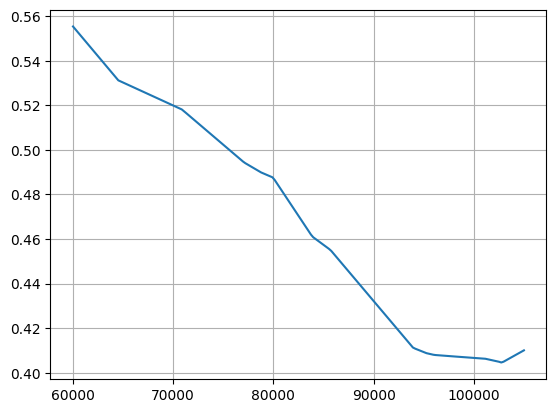

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# fsw sweep
F_values = np.linspace(60e3, 105e3, 200)

# 고정값
L1 = 0.0009915872795781893
L2 = 2.112814560102331e-05
C = 0.0004571868421441684

# 입력 행렬 생성 (200 x 3)
X_sweep = np.column_stack((
    np.full_like(F_values, L1),
    np.full_like(F_values, L2),
    np.full_like(F_values, C),
    F_values
))

# scaling
X_scaled = x_scaler.transform(X_sweep)

# ripple 예측 (한 번에!)
y_ripple_scaled = model_ripple.predict(X_scaled, verbose=0)

# inverse scaling
y_ripple_pred = y_ripple_scaler.inverse_transform(y_ripple_scaled)

# 분리
i_ripple_list = y_ripple_pred[:,0]
v_ripple_list = y_ripple_pred[:,1]

plt.figure()
plt.plot(F_values, i_ripple_list)
plt.grid(True)
plt.show()


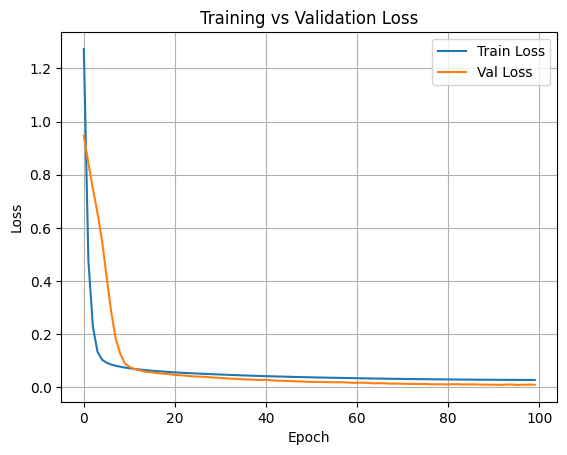

In [17]:
plt.figure()
plt.plot(history_ripple.history['loss'], label='Train Loss')
plt.plot(history_ripple.history['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

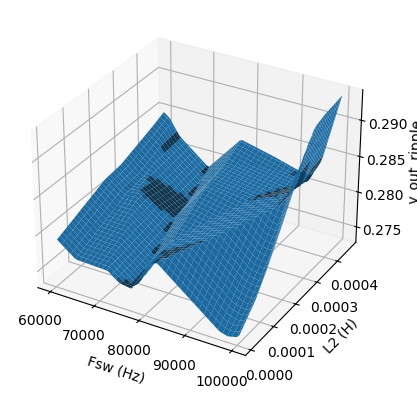

In [18]:
from mpl_toolkits.mplot3d import Axes3D

# sweep 범위 설정
F_values = np.linspace(60e3, 100e3, 80)
L2_values = np.linspace(1e-5, 46e-5, 80)

# 2D grid 생성
F_grid, L2_grid = np.meshgrid(F_values, L2_values)

L1 = 0.0001
C  = 0.00046

# 전체 조합 → 80*80 = 6400개
X_sweep = np.column_stack((
    np.full(F_grid.size, L1),
    L2_grid.ravel(),
    np.full(F_grid.size, C),
    F_grid.ravel()
))

# scaling
X_scaled = x_scaler.transform(X_sweep)

# 예측
y_ripple_scaled = model_ripple.predict(X_scaled, verbose=0)

# inverse scaling
y_ripple_pred = y_ripple_scaler.inverse_transform(y_ripple_scaled)

# ripple 값 reshape
i_ripple = y_ripple_pred[:,1].reshape(F_grid.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(F_grid, L2_grid, i_ripple)

ax.set_xlabel("Fsw (Hz)")
ax.set_ylabel("L2 (H)")
ax.set_zlabel("v_out_ripple")

plt.show()